<a href="https://colab.research.google.com/github/codewithfifa/CODSOFT_AI/blob/main/Task5_Face_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Image downloaded successfully!
🎯 Detected 1 face(s) in the image!


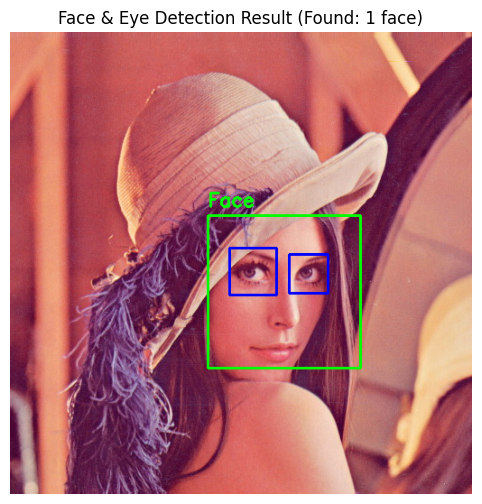

In [1]:
import urllib.request
import cv2
import matplotlib.pyplot as plt

# ----------------- 1. DOWNLOAD A SAMPLE IMAGE -----------------
# We download a sample group photo to test face detection
image_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
image_path = "sample_image.jpg"
urllib.request.urlretrieve(image_url, image_path)

print("✅ Image downloaded successfully!")

# ----------------- 2. LOAD PRE-TRAINED HAAR CASCADE -----------------
# OpenCV includes pre-trained face detection models by default
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

# ----------------- 3. READ & PROCESS THE IMAGE -----------------
# Read image
image = cv2.imread(image_path)

# Convert to grayscale (face detection models work best on grayscale)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect faces in the image
# scaleFactor: how much the image size is reduced at each scale
# minNeighbors: how many neighbors each candidate rectangle should have to retain it
faces = face_cascade.detectMultiScale(
    gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
)

print(f"🎯 Detected {len(faces)} face(s) in the image!")

# ----------------- 4. DRAW BOUNDING BOXES -----------------
for x, y, w, h in faces:
    # Draw green rectangle around the face
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(
        image,
        "Face",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2,
    )

    # Detect eyes within the face area
    roi_gray = gray[y : y + h, x : x + w]
    roi_color = image[y : y + h, x : x + w]
    eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=10)
    for ex, ey, ew, eh in eyes:
        # Draw blue rectangle around eyes
        cv2.rectangle(
            roi_color, (ex, ey), (ex + ew, ey + eh), (255, 0, 0), 2
        )

# ----------------- 5. DISPLAY THE OUTPUT -----------------
# Convert BGR (OpenCV format) to RGB (Matplotlib format) for correct colors
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title(f"Face & Eye Detection Result (Found: {len(faces)} face)")
plt.axis("off")
plt.show()
